Para esta notebook se usan los Datos Históricos de **Altura** de la **Estacion 3050 - Túnel Subfluvial**

Fuente: https://snih.hidricosargentina.gob.ar

In [ ]:
# Importo librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Importación del dataset

- Importamos sin la primer fila, que es el titulo y no forma parte de la tabla
- Corregimos el tipo de la columna Fecha y Hora, para que pandas sepa que es un dato de tiempo

In [ ]:
url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/Altura-Estacion3050.xlsx"

datos = pd.read_excel(url, header = 1)


In [ ]:
datos["Fecha y Hora"] = pd.to_datetime(datos["Fecha y Hora"],
                                       dayfirst = True)

datos = datos.rename(columns={"Altura [m]": "Altura"})    # Acortamos el nombre para simplificar

datos.head()

,Fecha y Hora,Altura
0,1904-01-25 04:43:00,3.78
1,1904-01-26 04:43:00,3.79
2,1904-01-27 04:43:00,3.84
3,1904-01-28 04:43:00,3.87
4,1904-01-29 04:43:00,3.89


In [ ]:
print(f'El dataset es de tamaño: {datos.shape}')              # (Número de observaciones, Número de variables)

El dataset es de tamaño: (88932, 2)


## Pre-procesamiento de los datos

Sumo toda la precipitación correspondiente al mismo día para tener un sólo valor para cada día


In [ ]:
datos["Fecha"] = datos["Fecha y Hora"].dt.normalize() # Creo columna con información solo de la fecha

datos = datos.groupby("Fecha")["Altura"].mean().reset_index() # Agrupo los datos por día y tomo la media
datos

,Fecha,Altura
0,1904-01-25,3.780000
1,1904-01-26,3.790000
2,1904-01-27,3.840000
3,1904-01-28,3.870000
4,1904-01-29,3.890000
...,...,...
44268,2026-07-27,2.691250
44269,2026-07-28,2.711667
44270,2026-07-29,2.743750
44271,2026-07-30,2.780417


Chequeamos qué fechas no tienen datos

In [ ]:
fechas_esperadas = pd.date_range(
                              start = datos["Fecha"].min(),
                              end = datos["Fecha"].max(),
                              freq = "D"
                          )

fechas_faltantes = fechas_esperadas.difference(datos["Fecha"])

print("Cantidad de días faltantes:", len(fechas_faltantes))
print(fechas_faltantes)

Cantidad de días faltantes: 476
DatetimeIndex(['1904-04-01', '1904-04-02', '1904-04-03', '1904-04-04',
               '1904-04-05', '1904-04-06', '1904-04-07', '1904-04-08',
               '1904-04-09', '1904-04-10',
               ...
               '2019-10-22', '2019-10-23', '2019-10-24', '2019-10-25',
               '2019-10-26', '2019-10-27', '2019-10-28', '2019-10-29',
               '2019-10-30', '2019-10-31'],
              dtype='datetime64[ns]', length=476, freq=None)


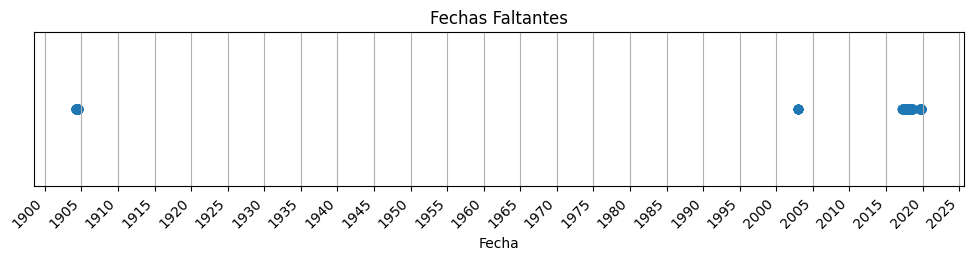

In [ ]:
import matplotlib.dates as mdates # Libreria que sirve para hacer el grid del plot más personalizable

plt.figure(figsize=(12, 2))

plt.scatter(
            fechas_faltantes,
            [1] * len(fechas_faltantes)
        )

plt.yticks([])
plt.xlabel("Fecha")
plt.title("Fechas Faltantes")
plt.grid()

plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))        # Permite hacer el grid cada 5 años
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')                             # Pone los valores del eje x en 45º

plt.show()

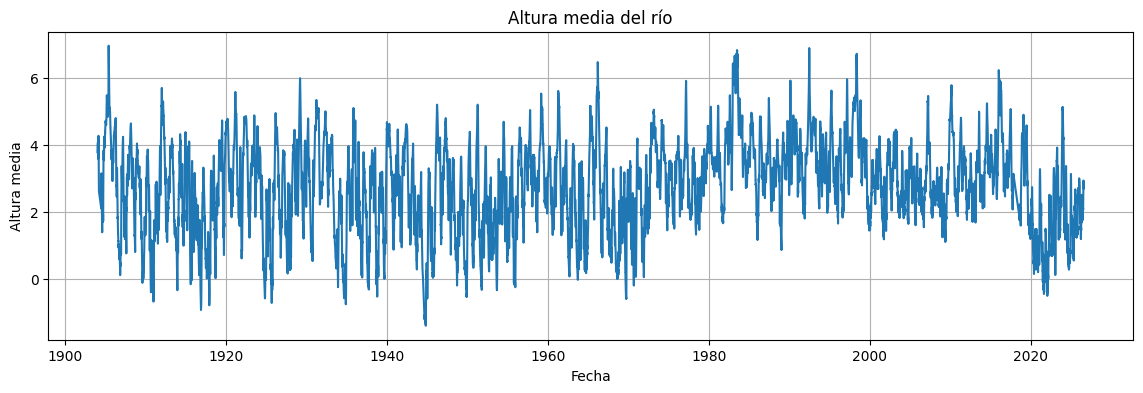

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(datos['Fecha'], datos["Altura"])

plt.title("Altura media del río")
plt.xlabel("Fecha")
plt.ylabel("Altura media")

plt.grid(True)
plt.show()

## Separación del dataset para entrenamiento y test

Para poder analizar los métodos de pronóstico en esta notebook, dividimos los datos.
- Los datos hasta 2010 para predecir.
- Los datos desde el 2010 se van a comparar con las predicciones.

In [ ]:
datos_train = datos[datos['Fecha'] <= "2009-12-31"].copy()

datos_test = datos[datos['Fecha'] >= "2010-01-01"].copy()

print("Observaciones de entrenamiento:", len(datos_train))
print("Observaciones de test:", len(datos_test))

Observaciones de entrenamiento: 38578
Observaciones de test: 5695


En las observaciones de entrenamiento vamos a rellenar los datos faltantes mediante interpolación (podría aplicarse otro método que se considere conveniente)

In [ ]:
fechas_esperadas = fechas_esperadas[fechas_esperadas <= "2009-12-31"] # Las fechas esperadas en el dataset de train son solo hasta el 2010

In [ ]:
datos_train = (datos_train.set_index("Fecha")             # Usa temporalmente Fecha como índice
                      .reindex(fechas_esperadas)          # Reemplaza el índice por fechas_esperadas
                      .rename_axis("Fecha")               # Asigna el nombre "Fecha" al nuevo índice
                      .reset_index())                     # Convierte nuevamente el índice Fecha en una columna

datos_train["Altura"] = datos_train["Altura"].interpolate()

In [ ]:
datos_train['Fecha'].max()

Timestamp('2009-12-31 00:00:00')

In [ ]:
datos_train.isna().sum() # Chequeamos que en el dataset de train no hay datos vacios

,0
Fecha,0
Altura,0


In [ ]:
print("Observaciones de entrenamiento después de completar:", len(datos_train))

Observaciones de entrenamiento después de completar: 38693


## Método de la Media

Considera que el valor futuro será el valor medio de todos los valores de altura en el dataset de entrenamiento

$$
\hat{y}_{T+h | T} = \frac{1}{T} \sum_{i = 1}^T y_i
$$

In [ ]:
media_train = datos_train['Altura'].mean()

# Genera una serie con las predicciones para todas las fechas del test
pred_mean = pd.Series(media_train,
                      index = datos_test['Fecha'],
                      name = 'Mean')

print("Media del entrenamiento:", media_train)

Media del entrenamiento: 2.7917409049009723


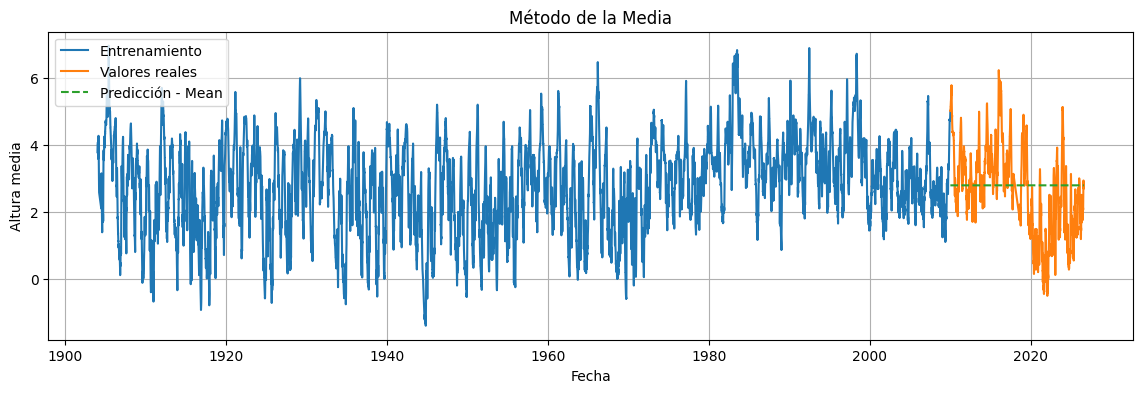

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(datos_train['Fecha'], datos_train['Altura'], label="Entrenamiento")
plt.plot(datos_test['Fecha'], datos_test['Altura'], label="Valores reales")
plt.plot(pred_mean, label="Predicción - Mean", linestyle="--")

plt.title("Método de la Media")
plt.xlabel("Fecha")
plt.ylabel("Altura media")
plt.legend()
plt.grid(True)
plt.show()

## Método Ingenuo (Naive)

Considera que el valor futuro será igual al último valor de altura de los datos de entrenamiento

$$
\hat{y}_{T+h | T} = y_T
$$

In [ ]:
ultimo_valor = datos_train['Altura'].iloc[-1] # Último valor de altura observado en el entrenamiento

# Genera un vector de predicciones para todas las fechas del test
pred_naive = pd.Series(ultimo_valor,
                      index = datos_test['Fecha'],
                      name='Naive')

print("Último valor del entrenamiento:", ultimo_valor)

Último valor del entrenamiento: 5.02


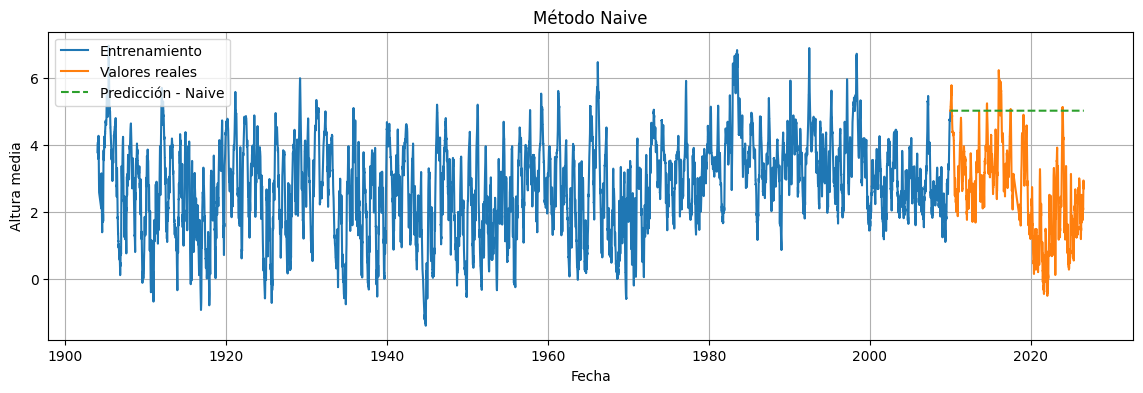

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(datos_train['Fecha'], datos_train['Altura'], label="Entrenamiento")
plt.plot(datos_test['Fecha'], datos_test['Altura'], label="Valores reales")
plt.plot(pred_naive, label="Predicción - Naive", linestyle="--")

plt.title("Método Naive")
plt.xlabel("Fecha")
plt.ylabel("Altura media")
plt.legend()
plt.grid(True)
plt.show()

## Método Ingenuo Estacional (Seasonal Naive)

Considera que el valor futuro de un día será igual al valor observado en el mismo período de la temporada anterior

$$
\hat{y}_{T+h | T} = y_{T + h - m(k+1)} \quad k = \frac{h - 1}{m}
$$


En nuestro caso suponemos una **estacionalidad anual** (m = 365)

In [ ]:
ultimo_ciclo = datos_train['Altura'].iloc[-365:].values # Tomamos los últimos 365 valores

valores_pred = np.resize(ultimo_ciclo, len(datos_test['Altura'])) # Repetimos el ciclo tantas veces como sea necesario

# Genera una serie con las predicciones para todas las fechas del test
pred_seasonal_naive = pd.Series(valores_pred,
                                index = datos_test['Fecha'],
                                name = 'Seasonal Naive')

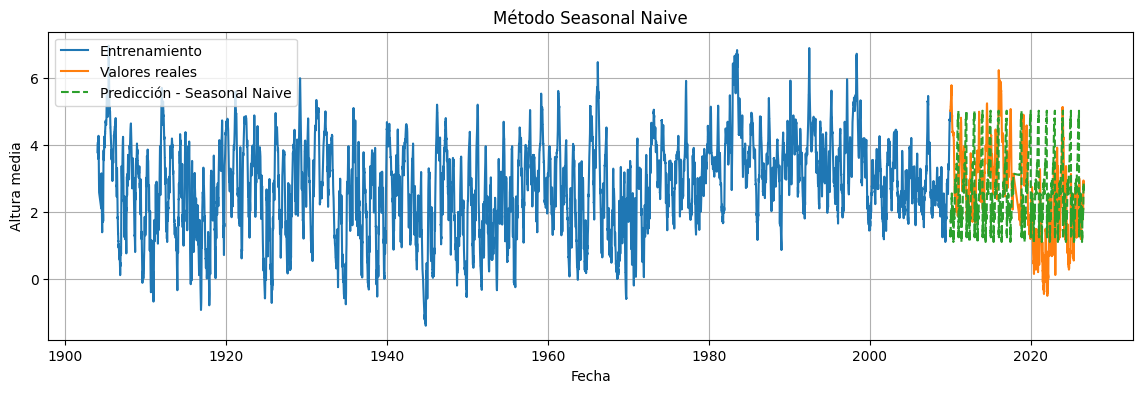

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(datos_train['Fecha'], datos_train['Altura'], label = "Entrenamiento")
plt.plot(datos_test['Fecha'], datos_test['Altura'], label = "Valores reales")
plt.plot(pred_seasonal_naive, label = "Predicción - Seasonal Naive", linestyle="--")

plt.title("Método Seasonal Naive")
plt.xlabel("Fecha")
plt.ylabel("Altura media")
plt.legend()
plt.grid(True)
plt.show()

## Método de la Deriva (Drift)

Considera que el valor futuro será obtenido mediante la tendencia promedio observada entre el primer y el último valor del entrenamiento

$$
\hat{y}_{T+h | T} = y_T + \frac{h}{T-1} \sum_{t=2}^T (y_t - y_{t-1}) = y_T + h \frac{y_T - y_1}{T-1}
$$

In [ ]:
# Primer y último valor del entrenamiento
y1 = datos_train['Altura'].iloc[0]
yT = datos_train['Altura'].iloc[-1]

# Cantidad de observaciones
T = len(datos_train['Altura'])

# Pendiente promedio por observación
drift = (yT - y1) / (T - 1)

print("Primer valor:", y1)
print("Último valor:", yT)
print("Drift por observación:", drift)

Primer valor: 3.78
Último valor: 5.02
Drift por observación: 3.2047968572314685e-05


In [ ]:
horizontes = np.arange(1, len(datos_test) + 1)

pred_drift_values = yT + horizontes * drift

# Crear serie con las fechas del test
pred_drift = pd.Series(pred_drift_values,
                      index = datos_test['Fecha'],
                      name = 'Drift')

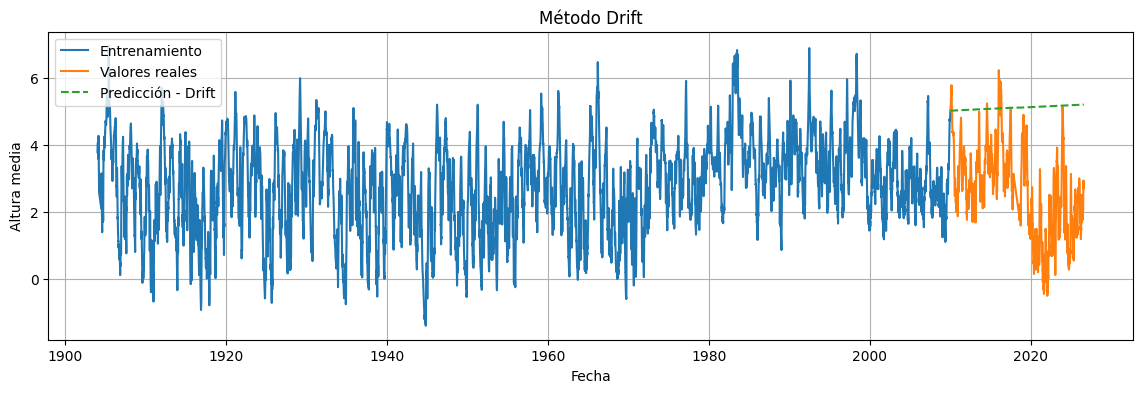

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(datos_train['Fecha'], datos_train['Altura'], label = "Entrenamiento")
plt.plot(datos_test['Fecha'], datos_test['Altura'], label = "Valores reales")
plt.plot(pred_drift, label = "Predicción - Drift", linestyle="--")

plt.title("Método Drift")
plt.xlabel("Fecha")
plt.ylabel("Altura media")
plt.legend()
plt.grid(True)
plt.show()

## Comparación de todos los métodos

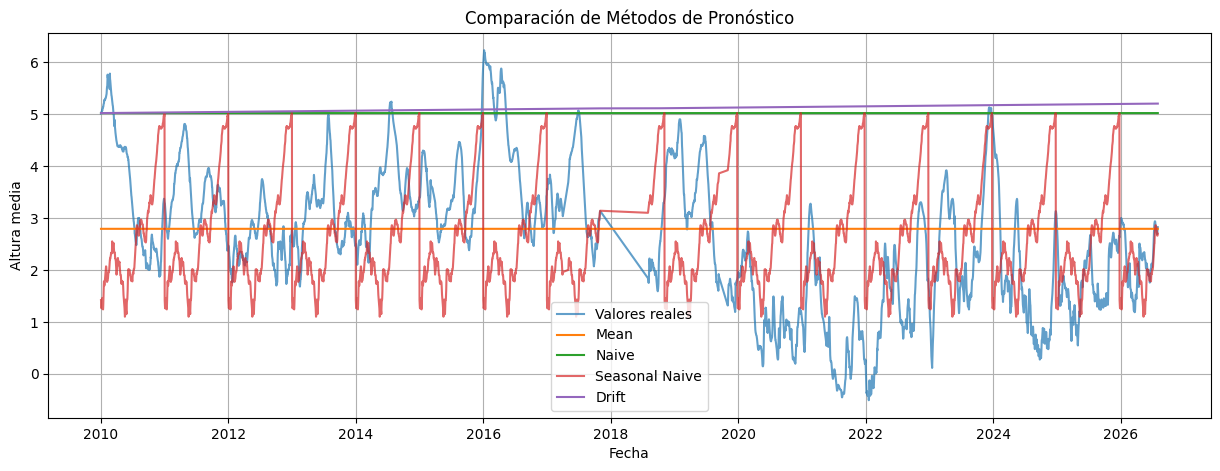

In [ ]:
plt.figure(figsize = (15, 5))

plt.plot(datos_test['Fecha'], datos_test['Altura'], label = "Valores reales", alpha = 0.7)

plt.plot(pred_mean, label = "Mean")

plt.plot(pred_naive, label = "Naive")

plt.plot(pred_seasonal_naive, label = "Seasonal Naive", alpha = 0.7)

plt.plot(pred_drift, label = "Drift")

plt.title("Comparación de Métodos de Pronóstico")
plt.xlabel("Fecha")
plt.ylabel("Altura media")
plt.legend()
plt.grid(True)
plt.show()

### Cálculo de métricas de comparación
* **MAE** (Mean Absolute Error): Error Absoluto Promedio
* **MSE**  (Mean Squared Error): Erro Cuadrático Medio
* **RMSE** (Root Mean Squared Error): Raíz del Error Cuadrático Medio
* **MAPE** (Mean Absolute Percentage Error): Error porcentual absoluto medio







#### Puede ser con las ecuaciones matemáticas

In [ ]:
def calcular_metricas(real, pred, nombre_metodo):

    pred = pred.to_numpy()

    error = real - pred

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    mape = np.mean(np.abs(error / real)) * 100

    return {
        "Método": nombre_metodo,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }


In [ ]:
resultados = []

resultados.append(calcular_metricas(datos_test["Altura"], pred_mean, "Mean"))
resultados.append(calcular_metricas(datos_test["Altura"], pred_naive, "Naive"))
resultados.append(calcular_metricas(datos_test["Altura"], pred_seasonal_naive, "Seasonal Naive"))
resultados.append(calcular_metricas(datos_test["Altura"], pred_drift, "Drift"))

tabla_metricas = pd.DataFrame(resultados).set_index("Método")
tabla_metricas = tabla_metricas.sort_values("RMSE")  # Ordenamos de mejor a peor según RMSE

tabla_metricas


,MAE,RMSE,MAPE (%)
Método,,,
Mean,1.072575,1.340306,283.087170
Seasonal Naive,1.445832,1.766798,263.656187
Naive,2.418183,2.727316,547.219143
Drift,2.505514,2.820148,562.244059


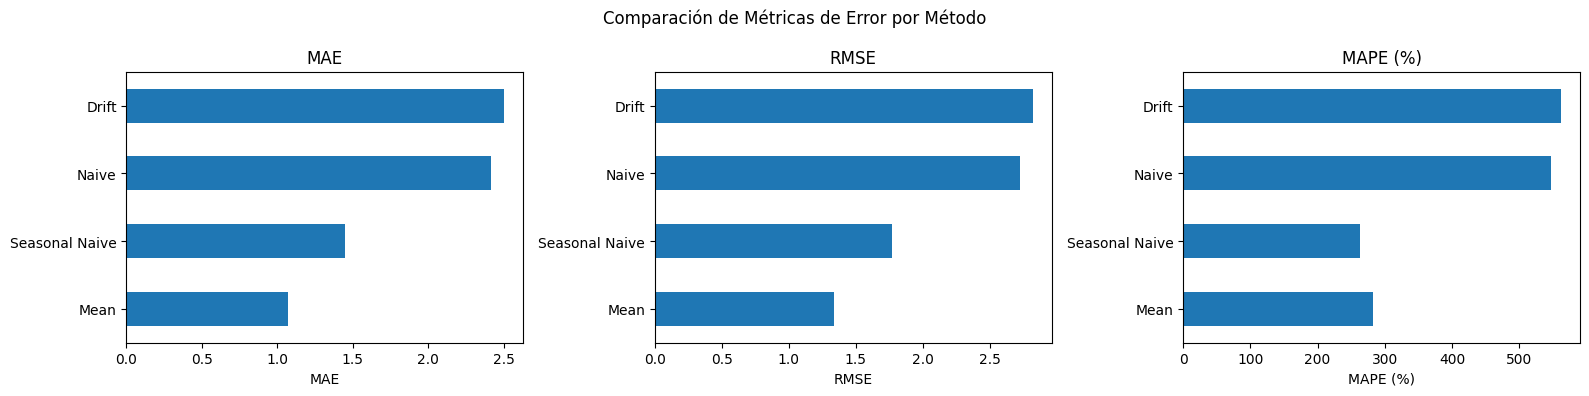

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metricas = ["MAE", "RMSE", "MAPE (%)"]

for ax, metrica in zip(axes, metricas):
    tabla_metricas[metrica].plot(kind="barh", ax = ax)
    ax.set_title(metrica)
    ax.set_xlabel(metrica)
    ax.set_ylabel("")

plt.suptitle("Comparación de Métricas de Error por Método")
plt.tight_layout()
plt.show()


#### O podemos usar una librería que ya tiene la funciones de cálculo definidas

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error


def calcular_metricas_sklearn(real, pred, nombre_metodo):

    pred = pred.to_numpy()

    mae = mean_absolute_error(real, pred)

    mse = mean_squared_error(real, pred)

    rmse = root_mean_squared_error(real, pred)

    mape = mean_absolute_percentage_error(real, pred) * 100

    return({
        "Método": nombre_metodo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape
    })


resultados = []

resultados.append(calcular_metricas_sklearn(datos_test["Altura"], pred_mean, "Mean"))
resultados.append(calcular_metricas_sklearn(datos_test["Altura"], pred_naive, "Naive"))
resultados.append(calcular_metricas_sklearn(datos_test["Altura"], pred_seasonal_naive, "Seasonal Naive"))
resultados.append(calcular_metricas_sklearn(datos_test["Altura"], pred_drift, "Drift"))

tabla_metricas = pd.DataFrame(resultados).set_index("Método")
tabla_metricas = tabla_metricas.sort_values("RMSE")  # Ordenamos de mejor a peor según RMSE

tabla_metricas


,MAE,MSE,RMSE,MAPE (%)
Método,,,,
Mean,1.072575,1.796421,1.340306,283.087170
Seasonal Naive,1.445832,3.121575,1.766798,263.656187
Naive,2.418183,7.438255,2.727316,547.219143
Drift,2.505514,7.953235,2.820148,562.244059


###  Evolución del error por año

In [ ]:
def metricas_por_año(real, pred, nombre_metodo):

    df = pred.to_frame(name = "Pred")     # Creamos una tabla (dataframe) con los datos de la prediccion. Le ponemos nombre 'Pred' a la columna de la tabla con estos valores

    df["Real"] = real.to_numpy()   # Agregamos una columna con los valores reales de altura
                                                   # Usamos el to_numpy porque son tablas con indices distintos y
                                                   # va a generarse un error porque pandas intenta alinear los valores
                                                   # por índice

    df["Año"] = df.index.year      # Agregamos una columna con el número de año

    filas = []

    for año, grupo in df.groupby("Año"): # Agrupamos los datos de la tabla por año

        error = grupo["Real"] - grupo["Pred"]
        mae = np.mean(np.abs(error))
        rmse = np.sqrt(np.mean(error**2))
        mape = np.mean(np.abs(error / grupo["Real"])) * 100

        filas.append({
            "Año": año,
            "Método": nombre_metodo,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE (%)": mape
        })

    return pd.DataFrame(filas)


In [ ]:
metricas_anuales = pd.concat([
                                metricas_por_año(datos_test["Altura"], pred_mean, "Mean"),
                                metricas_por_año(datos_test["Altura"], pred_naive, "Naive"),
                                metricas_por_año(datos_test["Altura"], pred_seasonal_naive, "Seasonal Naive"),
                                metricas_por_año(datos_test["Altura"], pred_drift, "Drift"),
                            ])

metricas_anuales.head()


,Año,Método,MAE,RMSE,MAPE (%)
0,2010,Mean,1.147686,1.444885,28.629566
1,2011,Mean,0.731675,0.916238,19.053353
2,2012,Mean,0.460200,0.545345,20.157647
3,2013,Mean,0.544506,0.731962,16.680846
4,2014,Mean,0.848157,1.045821,22.139550


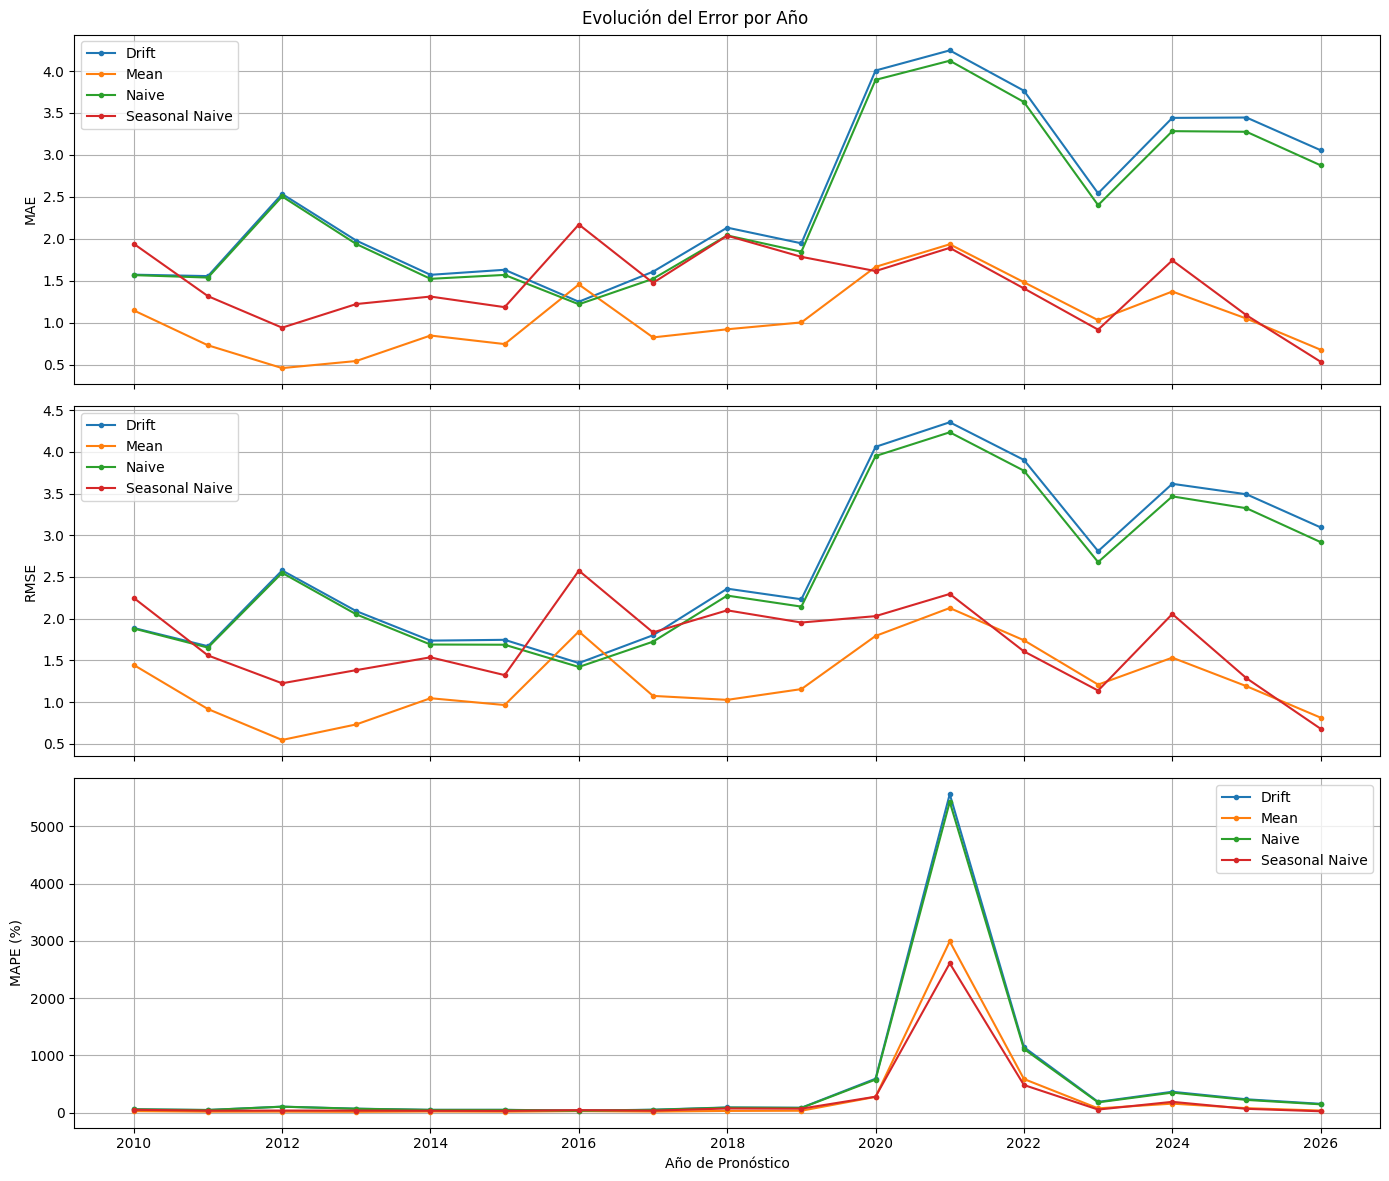

In [150]:
fig, axes = plt.subplots(3, 1, figsize = (14, 12), sharex=True) # Los primeros 2 parámetros permiten indicar número de filas y columnas en la figura
                                                                # (creando en este caso 3 subfiguras una abajo de la otra)

metricas = ["MAE", "RMSE", "MAPE (%)"]

for ax, metrica in zip(axes, metricas): # Va recorrer tanto la lista de axes (indice de cada subfigura) como la de métricas
                                        # De manera que cada métrica va a ser graficada en una subfigura distinta

    for metodo, grupo in metricas_anuales.groupby("Método"): # Agrupo los resultados de las metricas segun el metodo al que corresponden
        ax.plot(grupo["Año"], grupo[metrica], label = metodo, marker = "o", markersize = 3)

    ax.set_ylabel(metrica)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Año de Pronóstico")
fig.suptitle("Evolución del Error por Año")
plt.tight_layout()
plt.show()
